In [819]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import jensenshannon
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
import random

# prepare the labels y

In [820]:
dataset = pd.read_parquet('../kinpfn_testing_set/parquet_parsing/test_val_dataset.parquet')

In [821]:
arr_fpts = np.array([row for row in dataset['fpts']])

In [822]:
arr_fpts.shape

(2654, 1000)

In [823]:
np.min(arr_fpts)

0.0

In [824]:
np.max(arr_fpts)

297458098.413

In [825]:
np.where(arr_fpts == 0)

(array([ 251,  258,  274,  274,  274,  274,  274,  274,  274,  333,  349,
         349,  453,  459,  464,  465,  465,  465,  465,  478,  480,  480,
         482,  484,  484,  484,  484,  491,  491,  491,  491,  527, 1373,
        1441, 1490, 1490, 1490, 1497, 1510, 1510, 1510, 1514, 1514, 1531,
        1897, 2157, 2167, 2167, 2179, 2183, 2201, 2220, 2235, 2245, 2248,
        2253, 2253, 2255, 2256, 2256, 2257, 2267, 2282, 2282, 2282, 2295,
        2296, 2296, 2298, 2298, 2316, 2316, 2322, 2328, 2328, 2328, 2355,
        2355, 2361, 2361, 2361, 2381, 2381, 2390, 2446]),
 array([ 81, 180, 186, 211, 222, 408, 472, 555, 965, 153, 412, 864, 560,
         11, 389,  66, 250, 625, 641, 903, 420, 612, 230, 276, 306, 452,
        783,  40, 141, 432, 792, 643, 805, 460, 148, 175, 728, 730, 208,
        270, 368, 777, 928, 529, 320, 454, 468, 774, 626,  53, 920, 921,
        808, 525, 892, 135, 360, 589, 617, 702, 865, 711,  70, 601, 719,
        792, 226, 597, 553, 751,   8, 332, 531, 396, 552, 6

In [826]:
where_arr_fpts_nonzero = np.where(arr_fpts != 0)
arr_logfpts = np.log(arr_fpts[where_arr_fpts_nonzero])

In [827]:
np.min(arr_logfpts)

-6.907755278982137

In [828]:
np.max(arr_logfpts)

19.510783927359686

In [829]:
arr_logfpts.shape

(2653915,)

In [830]:
n_bins = 50

binedges_logfpt = np.linspace(np.min(arr_logfpts), np.max(arr_logfpts), n_bins+1)

In [831]:
arr_hist_logfpts = np.zeros((dataset.shape[0], n_bins))
for index, row in dataset.iterrows():
    fpts = row['fpts']
    where_fpts_nonzero = np.where(fpts != 0)
    logfpts = np.log(fpts[where_fpts_nonzero])
    hist_logfpts, _ = np.histogram(logfpts, binedges_logfpt, density=True)
    hist_logfpts /= np.sum(hist_logfpts) # normalize so that values add to 1; this does not reflect the probability density
    arr_hist_logfpts[index] = hist_logfpts


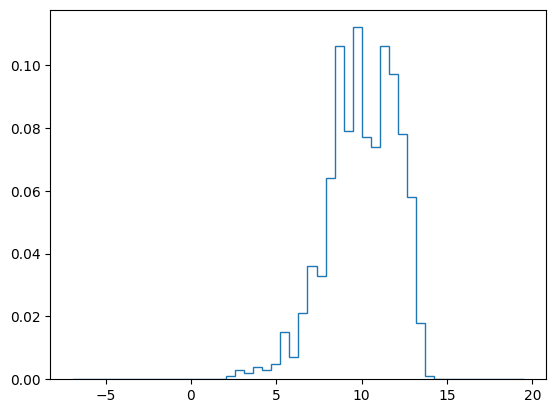

In [832]:
plt.stairs(arr_hist_logfpts[67], binedges_logfpt)

In [833]:
y = arr_hist_logfpts

In [834]:
np.sum(y, axis=1)

array([1., 1., 1., ..., 1., 1., 1.])

In [835]:
print(y.shape)

(2654, 50)


# prepare the features X

In [836]:
print(dataset.columns)

Index(['filepath', 'sequence', 'length', 'mfe_from_file',
       'dot_bracket_from_file', 'fpts', 'gc_content', 'freq_A', 'freq_U',
       'freq_G',
       ...
       'min_11_tree_dist', 'min_12_tree_dist', 'min_13_tree_dist',
       'min_14_tree_dist', 'min_15_tree_dist', 'min_16_tree_dist',
       'min_17_tree_dist', 'min_18_tree_dist', 'min_19_tree_dist',
       'min_20_tree_dist'],
      dtype='str', length=110)


In [837]:
X = dataset.drop(columns=['filepath', 'dot_bracket_from_file', 'fpts'])
for i in range(1, 21):
    X = X.drop(columns=['min_'+str(i)+'_structure'])
    X = X.drop(columns=['min_'+str(i)+'_energy'])
    X = X.drop(columns=['min_'+str(i)+'_bp_dist'])
    X = X.drop(columns=['min_'+str(i)+'_tree_dist'])
for i in ['A' , 'C' , 'G' , 'U']:
    for j in ['A', 'C', 'G', 'U', '']:
        X = X.drop(columns=['freq_'+ i + j])

In [838]:
X.shape

(2654, 7)

In [839]:
with pd.option_context('display.max_rows', None):
    print(X.iloc[0:3])

                                            sequence  length  mfe_from_file  \
0  UCAUACAGACUUAGAUAAGAAGCCGGCACUUUUAGUCCGUCUGAAU...     100         -29.30   
1  CGCUACGGUUAUCAGACUUGAUUGUAGAGGAACAUUAAGCGGAGGA...     100         -39.60   
2  GUCUGUUUAUGGAAGGUUAUUCCGUCCCGAUAGGAUUACAACAAAU...     100         -24.14   

   gc_content        mfe                                      mfe_structure  \
0        0.53 -29.299999  ((((.(((((...(((.(((((......))))).))).))))).))...   
1        0.54 -39.599998  (.(((((((((.......))))))))).).........(((..(((...   
2        0.43 -24.299999  ..(((((.((((((.....)))))).....(((((((......)))...   

   n_local_minima  
0              26  
1               8  
2              39  


In [840]:
# X = np.array(X)

In [841]:
X.shape

(2654, 7)

In [842]:
y.shape

(2654, 50)

# train the model

In [843]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, random_state=42)


In [844]:
scaler = StandardScaler()

handpicked_cols = ['gc_content', 'mfe', 'n_local_minima']

#pull out the numerical features for normalization 
X_train_static = scaler.fit_transform(X_train[handpicked_cols])
X_val_static   = scaler.transform(X_val[handpicked_cols])
X_test_static  = scaler.transform(X_test[handpicked_cols])

#bucket into same-length batches so no need to pad
def bucket_and_extract(sequences, scaled_static_array, y):
    # Get the indices that would sort by length
    sort_indices = np.argsort(sequences['length'].values)
    
    # Use iloc to index the DataFrame rows directly
    sorted_df = sequences.iloc[sort_indices]
    
    # Pull out the two columns you need as plain lists
    sorted_seq       = sorted_df['sequence'].tolist()
    sorted_structure = sorted_df['mfe_structure'].tolist()
    
    sorted_static  = scaled_static_array[sort_indices]
    sorted_targets = y[sort_indices] if isinstance(y, np.ndarray) else y.iloc[sort_indices].values
    
    return sorted_seq, sorted_structure, sorted_static, sorted_targets

# Apply bucketing to each split separately
train_seq, train_structure, train_static, train_y = bucket_and_extract(X_train, X_train_static, y_train)
val_seq,   val_structure,   val_static,   val_y   = bucket_and_extract(X_val, X_val_static, y_val)
test_seq,  test_structure,  test_static,  test_y  = bucket_and_extract(X_test, X_test_static, y_test)

nuc_map    = {'A': [1,0,0,0], 'U': [0,1,0,0], 'G': [0,0,1,0], 'C': [0,0,0,1]}
struct_map = {'.': [1,0,0],   '(': [0,1,0],   ')': [0,0,1]}

def encode_sequence(seq):
    # Returns array of shape (seq_len, 2)
    nuc    = [nuc_map[c] for c in seq]
    return np.array(nuc, dtype=np.float32)
def encode_struct(seq):
    struct = [struct_map[c] for c in seq]
    return np.array(struct, dtype=np.float32)

train_seq_encoded = [encode_sequence(seq) for seq in train_seq]
val_seq_encoded   = [encode_sequence(seq) for seq in val_seq]
test_seq_encoded  = [encode_sequence(seq) for seq in test_seq]

train_struct_encoded = [encode_struct(seq) for seq in train_structure]
val_struct_encoded   = [encode_struct(seq) for seq in val_structure]
test_struct_encoded  = [encode_struct(seq) for seq in test_structure]

In [845]:
from torch.utils.data import Dataset, DataLoader, Sampler

# 1. The Dataset simply holds your pre-sorted numpy data
class RNASortedDataset(Dataset):
    def __init__(self, sequences, structures, static_features, targets):
        self.sequences = sequences       # List of arrays (sorted by length)
        self.structures = structures       # List of arrays (sorted by length)
        self.static_features = static_features # 2D NumPy array (sorted)
        self.targets = targets           # 1D NumPy array (sorted)
        self.len = len(self.sequences)
        

    def __len__(self):
        return self.len

    def __getitem__(self, idx):
        return self.sequences[idx], self.structures[idx], self.static_features[idx], self.targets[idx]

class ExactLengthBatchSampler(Sampler):
    def __init__(self, dataset):
        self.dataset = dataset
        self.length_to_indices = {}
        # Group indices by their sequence length
        # e.g., {15: [0, 1, 4, 12], 16: [2, 3, 5], ...}
        for idx in range(len(self.dataset)):
            length = len(self.dataset.sequences[idx]) 
            if length not in self.length_to_indices:
                self.length_to_indices[length] = []
            self.length_to_indices[length].append(idx)
            
        # Create a list of batches
        self.batches = list(self.length_to_indices.values())

    def __iter__(self):
        # Shuffle the order of the BATCHES themselves so the model 
        # doesn't always see short RNAs first and long RNAs last.
        np.random.shuffle(self.batches)
        for batch in self.batches:
            yield batch

    def __len__(self):
        return len(self.batches)


def dynamic_batch_collate(batch):
    # Because of our sampler, everything in 'batch' is guaranteed to be identical in length.
    seqs = np.array([item[0] for item in batch], dtype=np.float32)
    structures = np.array([item[1] for item in batch], dtype=np.float32)
    statics = np.array([item[2] for item in batch], dtype=np.float32)
    targets = np.array([item[3] for item in batch], dtype=np.float32)
    
    return torch.from_numpy(seqs), torch.from_numpy(structures), torch.from_numpy(statics), torch.from_numpy(targets)

In [846]:
from unicodedata import bidirectional


class DynamicHybridLSTM(nn.Module):
    def __init__(self, hidden_size, num_layers, handpicked_feature_size, output_size, mlp_hidden_size=64, bidirectional=False):
        super(DynamicHybridLSTM, self).__init__()
        # 1. The LSTM Layer
        # batch_first=True expects inputs of shape: (batch_size, sequence_length, feature_size)
        self.bi = bidirectional
        self.lstm = nn.LSTM(
            input_size=7, #one for dot bracket and one for raw sequence
            hidden_size=hidden_size,
            num_layers=num_layers,  
            batch_first=True,
            bidirectional=bidirectional
        )
        
        # 2. Calculating the input size for the MLP
        # The MLP receives the final hidden state of the LSTM concatenated with the static features
        mlp_input_size = hidden_size + handpicked_feature_size
        
        if self.bi:
            mlp_input_size += hidden_size
        
        # 3. The Fully Connected MLP Layers
        self.mlp = nn.Sequential(
            nn.Linear(mlp_input_size, mlp_hidden_size),
            nn.ReLU(),
            nn.Linear(mlp_hidden_size, output_size)
        )
    def forward(self, sequence, structure, handpicked_features):
        # sequence and structure shape: (batch_size, seq_len)
        # handpicked_features shape: (batch_size, handpicked_feature_size)
        
        x = torch.cat([sequence, structure], dim=-1)
    
        # 2. Pass through LSTM
        # lstm_out shape: (batch_size, seq_len, hidden_size)
        # hidden shape:  (num_layers, batch_size, hidden_size)
        lstm_out, (hidden, cell) = self.lstm(x)
        
        # 3. Extract the final hidden state from the last layer only
        # hidden[-1] shape: (batch_size, hidden_size)
        last_hidden = hidden[-1]
        combined = None

        if self.bi:
            last_hidden_fwd = hidden[-2] # Forward hidden state of the last layer
            
            # Concatenate them together to get the full bidirectional context
            # Shape: (batch_size, hidden_size * 2)
            last_hidden_bi = torch.cat([last_hidden_fwd, last_hidden], dim=-1)
            
            # 4. Concatenate LSTM hidden state with handpicked features
            # combined shape: (batch_size, (hidden_size * 2) + handpicked_feature_size)
            combined = torch.cat([last_hidden_bi, handpicked_features], dim=-1)
        else:
            combined = torch.cat([last_hidden, handpicked_features], dim=-1)

        output = self.mlp(combined)
        return output


In [847]:
X_train.shape

(1916, 7)

In [848]:
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [849]:
set_seed(42) # does this work
# does this hidden size make sense?
# --- Model, Loss, Optimizer ---
model = DynamicHybridLSTM(hidden_size=64, num_layers=1, handpicked_feature_size=train_static.shape[1], output_size=y_train.shape[1], mlp_hidden_size=64)
# criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
criterion = nn.KLDivLoss(reduction='batchmean')  # soft targets


# --- Build Datasets ---
train_dataset = RNASortedDataset(train_seq_encoded, train_struct_encoded, train_static, train_y)
val_dataset   = RNASortedDataset(val_seq_encoded,   val_struct_encoded,   val_static,   val_y)

# --- Build Samplers ---
train_sampler = ExactLengthBatchSampler(train_dataset)
val_sampler   = ExactLengthBatchSampler(val_dataset)

# --- Build DataLoaders ---
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, collate_fn=dynamic_batch_collate)
val_loader   = DataLoader(val_dataset,   batch_sampler=val_sampler, collate_fn=dynamic_batch_collate)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',        # minimize val loss
    factor=0.5,        # halve the LR on plateau
    patience=5,        # wait 5 epochs before reducing
    min_lr=1e-6        # don't go below this
)


In [ ]:

import math

train_losses, val_losses = [], []

best_val_loss = math.inf
EPOCHS = 100
for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0

    for sequences, structures, statics, targets in train_loader:
        optimizer.zero_grad()
        log_probs = torch.log_softmax(model(sequences, structures, statics), dim=-1)
        loss = criterion(log_probs.squeeze(), targets) 
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * len(targets)
    running_train_loss /= len(X_train)
    model.eval()


    running_val_loss = 0.0
    with torch.no_grad():
        for sequences, structures, statics, targets in val_loader:
            log_probs_val = torch.log_softmax(model(sequences, structures, statics), dim=-1)
            val_loss = criterion(log_probs_val.squeeze(), targets)
            running_val_loss += val_loss.item() * len(targets)
    
    running_val_loss /= len(X_val)

    train_losses.append(running_train_loss)
    val_losses.append(running_val_loss)

    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step(running_val_loss)
    new_lr = optimizer.param_groups[0]['lr']

    if new_lr != current_lr:
        print(f"Epoch {epoch+1} | LR dropped: {current_lr:.2e} → {new_lr:.2e}")
    
    if running_val_loss < best_val_loss:
        best_val_loss = running_val_loss
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Validation loss improved. Model saved to 'best_model.pth'")
    
 
    if epoch % 5 == 0:

      print(f"Epoch {epoch+1} | Train: {running_train_loss:.4f} | Val: {running_val_loss:.4f} | LR: {current_lr:.2e}")
    if epoch == EPOCHS - 1:
      print(f"Final Epoch {epoch+1} | Train: {running_train_loss:.4f} | Val: {running_val_loss:.4f} | LR: {current_lr:.2e}")

plt.plot(train_losses, label='Train')
plt.plot(val_losses, label='Val')
plt.xlabel('Epoch')
plt.ylabel('KL Divergence')
plt.legend()
plt.show()

Validation loss improved. Model saved to 'best_model.pth'
Epoch 1 | Train: 0.9163 | Val: 0.7362 | LR: 1.00e-03
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Epoch 6 | Train: 0.4387 | Val: 0.3932 | LR: 1.00e-03
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Epoch 11 | Train: 0.4043 | Val: 0.3724 | LR: 1.00e-03
Epoch 16 | Train: 0.4140 | Val: 0.3745 | LR: 1.00e-03
Epoch 17 | LR dropped: 1.00e-03 → 5.00e-04
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Validation loss improved. Model saved to 'best_model.pth'
Epoch 21 | Train: 0.3938 | Val: 0.3680 | LR: 5.

In [ ]:
model.eval()
running_val_loss = 0.0
all_preds = []
all_targets = []

with torch.no_grad():
    for sequences, structures, statics, targets in val_loader:
        preds = model(sequences, structures, statics)  # raw logits
        probs = torch.softmax(preds, dim=-1)           # softmax once
        
        val_loss = criterion(probs.squeeze(), targets)
        running_val_loss += val_loss.item() / len(val_loader)
        
        # Collect for JS divergence
        all_preds.append(probs.numpy())
        all_targets.append(targets.numpy())

val_losses.append(running_val_loss)
train_losses.append(running_train_loss)

# Stack all batches into one array for JS scoring
all_preds   = np.concatenate(all_preds,   axis=0)
all_targets = np.concatenate(all_targets, axis=0)

js_scores = [jensenshannon(all_targets[i], all_preds[i]) for i in range(len(all_targets))]
print(f"Mean JS divergence:   {np.mean(js_scores):.4f}")
print(f"Median JS divergence: {np.median(js_scores):.4f}")

Mean JS divergence:   0.3049
Median JS divergence: 0.2995


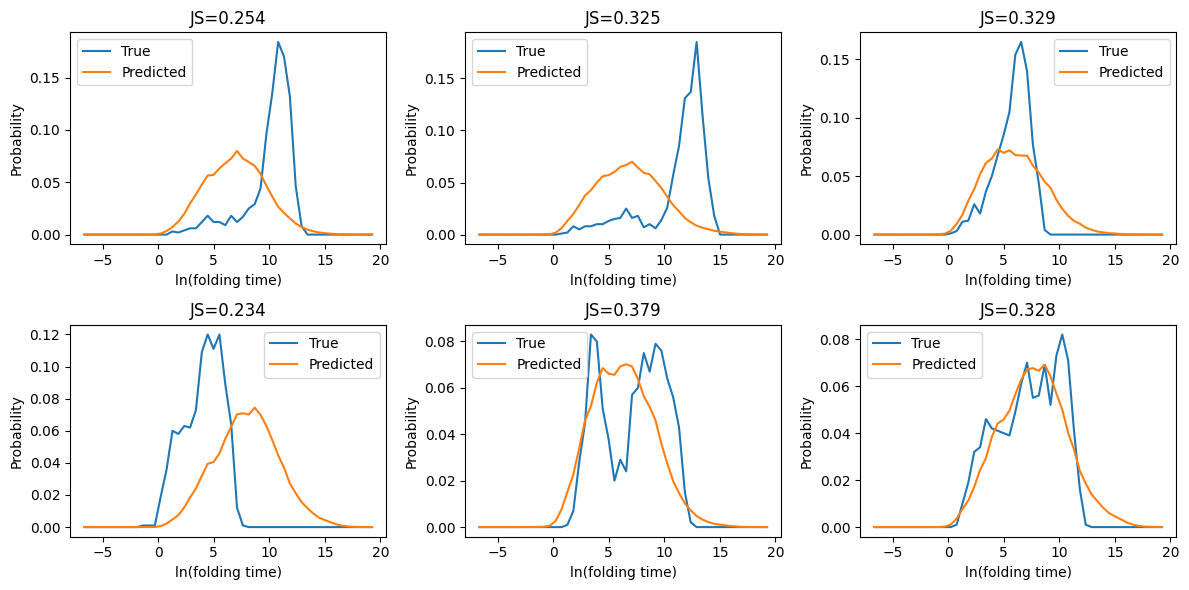

In [ ]:
bin_centers = (binedges_logfpt[:-1] + binedges_logfpt[1:]) / 2

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.plot(bin_centers, y_val[i], label='True')
    ax.plot(bin_centers, probs[i], label='Predicted')
    ax.set_title(f"JS={js_scores[i]:.3f}")
    ax.set_xlabel('ln(folding time)')
    ax.set_ylabel('Probability')
    ax.legend()
plt.tight_layout()
plt.show()